In [1]:
# Крок 1. Імпорти та налаштування графіків

import sys
import tempfile

sys.modules["cv2"] = None  # без цього cv2 і pygame сваряться за спільну бібліотеку

import numpy as np  # numpy має бути раніше за stable-baselines3, інакше конфлікт бібліотек
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import Image
import gymnasium as gym
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import logging as hub_logging
import torch as th
import stable_baselines3
from stable_baselines3 import PPO

hub_logging.set_verbosity_error()

plt.rcParams["figure.figsize"] = (9, 3.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.linewidth"] = 0.3
plt.rcParams["grid.alpha"] = 0.5
plt.rcParams["font.size"] = 9

print("gymnasium:", gym.__version__, "| stable-baselines3:", stable_baselines3.__version__)

gymnasium: 1.3.0 | stable-baselines3: 2.9.0


In [2]:
# Крок 2. Середовище: посадка місячного модуля

env = gym.make("LunarLander-v3", render_mode="rgb_array")
obs, info = env.reset(seed=42)

print("простір станів:", env.observation_space.shape, "| кількість дій:", env.action_space.n)

# Стан описується вісьмома числами. Дві останні ознаки бінарні: торкнулась опора землі чи ні.
state_names = ["позиція x", "позиція y", "швидкість x", "швидкість y",
               "кут", "кутова швидкість", "ліва опора торкається", "права опора торкається"]
print("\nпочатковий стан:")
for name, value in zip(state_names, obs):
    print(f"{name:>24}: {value: .3f}")

# Дій чотири, кожна це вмикання одного з двигунів або нічого.
action_names = ["нічого не робити", "лівий двигун", "головний двигун", "правий двигун"]
print("\nдії:", ", ".join(f"{i} - {name}" for i, name in enumerate(action_names)))

простір станів: (8,) | кількість дій: 4

початковий стан:
               позиція x:  0.002
               позиція y:  1.418
             швидкість x:  0.233
             швидкість y:  0.320
                     кут: -0.003
        кутова швидкість: -0.053
   ліва опора торкається:  0.000
  права опора торкається:  0.000

дії: 0 - нічого не робити, 1 - лівий двигун, 2 - головний двигун, 3 - правий двигун


розмір кадру: (400, 600, 3) | тип: uint8


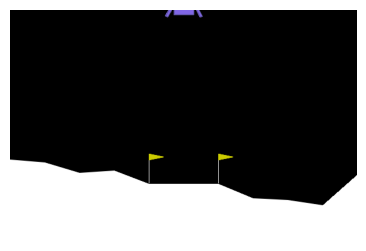

In [3]:
# Крок 3. Дивимось, як виглядає сцена на старті

frame = env.render()
print("розмір кадру:", frame.shape, "| тип:", frame.dtype)

plt.figure(figsize=(4.5, 3))
plt.imshow(frame)
plt.axis("off")
plt.show()

In [4]:
# Крок 4. Беремо готову модель з HuggingFace

# Це переднавчений PPO з розділу reinforcement learning, своєї моделі ми не тренуємо.
path = hf_hub_download(repo_id="sb3/ppo-LunarLander-v2", filename="ppo-LunarLander-v2.zip")

# Архів зберігали ще на старій бібліотеці gym, тому простори станів і дій з нього не читаються.
# Підставляємо свої: за формою вони збігаються, вісім чисел стану і чотири дії.
custom_objects = {
    "learning_rate": 0.0,
    "lr_schedule": lambda _: 0.0,
    "clip_range": lambda _: 0.0,
    "observation_space": env.observation_space,
    "action_space": env.action_space,
}
model = PPO.load(path, custom_objects=custom_objects, device="cpu")

print("алгоритм:", type(model).__name__, "| політика:", type(model.policy).__name__)
print("стан моделі:", model.observation_space.shape, "| дії моделі:", model.action_space.n)

алгоритм: PPO | політика: ActorCriticPolicy
стан моделі: (8,) | дії моделі: 4


зібрано кадрів: 100 | перезапусків сцени: 0
сумарна нагорода за випадкові дії: -133.0


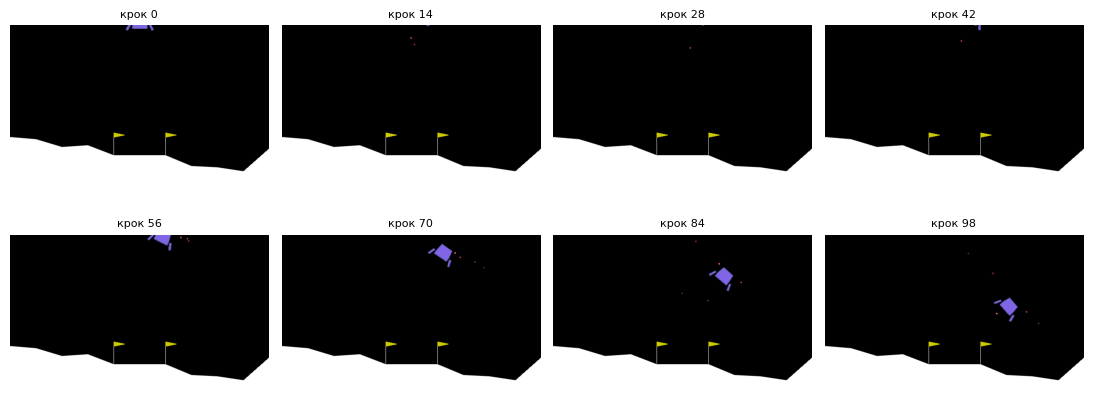

In [5]:
# Крок 5. Довільна послідовність кадрів

# Проходимо сцену навмання: на кожному кроці тиснемо випадкову дію і зберігаємо стан та кадр.
# Якщо модуль розбився або відлетів за межі, починаємо сцену наново і йдемо далі.
env.action_space.seed(42)
obs, info = env.reset(seed=42)

sequence_length = 100
states, frames, random_actions, random_rewards = [], [], [], []
restarts = 0

for step in range(sequence_length):
    states.append(obs)
    frames.append(env.render())
    action = env.action_space.sample()
    random_actions.append(int(action))
    obs, reward, terminated, truncated, info = env.step(action)
    random_rewards.append(reward)
    if terminated or truncated:
        obs, info = env.reset()
        restarts += 1

print("зібрано кадрів:", len(frames), "| перезапусків сцени:", restarts)
print("сумарна нагорода за випадкові дії:", round(float(np.sum(random_rewards)), 1))

# Дивимось кожен чотирнадцятий кадр, щоб побачити, що відбувається з модулем.
fig, axes = plt.subplots(2, 4, figsize=(11, 4.5))
for ax, i in zip(axes.ravel(), range(0, sequence_length, 14)):
    ax.imshow(frames[i])
    ax.set_title(f"крок {i}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

# На кроках 14-42 модуля майже не видно: випадкова тяга виштовхнула його вгору за межі екрана.
# Далі він падає назад, крутиться і до посадкового майданчика між прапорцями так і не наближається.

порад моделі: 100 | збіглося з випадковою дією: 22

скільки разів обрано кожну дію:
    нічого: випадково  22 | модель   0
     лівий: випадково  26 | модель  49
  головний: випадково  24 | модель  51
    правий: випадково  28 | модель   0


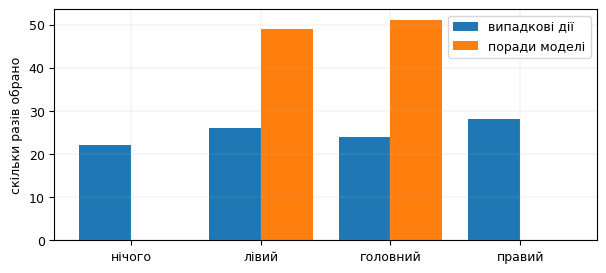

In [6]:
# Крок 6. Які дії радить модель для тих самих станів

# Проганяємо кожен збережений стан через модель і дивимось, що вона пропонує зробити.
predicted_actions = [int(model.predict(state, deterministic=True)[0]) for state in states]

matched = sum(1 for a, b in zip(random_actions, predicted_actions) if a == b)
print("порад моделі:", len(predicted_actions), "| збіглося з випадковою дією:", matched)

short_names = ["нічого", "лівий", "головний", "правий"]
random_counts = [random_actions.count(i) for i in range(4)]
model_counts = [predicted_actions.count(i) for i in range(4)]

print("\nскільки разів обрано кожну дію:")
for name, r, m in zip(short_names, random_counts, model_counts):
    print(f"{name:>10}: випадково {r:3d} | модель {m:3d}")

bar_positions = np.arange(4)
plt.figure(figsize=(7, 3))
plt.bar(bar_positions - 0.2, random_counts, width=0.4, label="випадкові дії")
plt.bar(bar_positions + 0.2, model_counts, width=0.4, label="поради моделі")
plt.xticks(bar_positions, short_names)
plt.ylabel("скільки разів обрано")
plt.legend()
plt.show()

# Випадковий вибір розкидано рівно між чотирма діями, а модель узяла лише дві: лівий і головний
# двигун. Вимкнених двигунів вона не радить жодного разу, тобто на цих станах постійно щось коригує.
# Збіг 22 зі 100 нічого не означає: модель тримається двох дій, а випадковий вибір з чотирьох
# потрапляє в них приблизно в чверті випадків.

оцінок: 100 | на початку 113.4 | у кінці 52.1
найнижча 52.1 | найвища 115.7 | середня 96.5


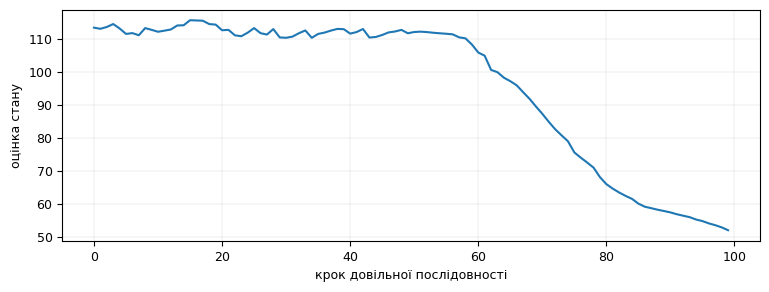

In [7]:
# Крок 7. Наскільки вигідними модель вважає ці стани

# Крім дії модель уміє оцінити сам стан: скільки нагороди вона очікує набрати далі з нього.
state_values = []
for state in states:
    state_tensor, _ = model.policy.obs_to_tensor(state)
    with th.no_grad():
        state_values.append(float(model.policy.predict_values(state_tensor)))

state_values = np.array(state_values)
print(f"оцінок: {len(state_values)} | на початку {state_values[0]:.1f}"
      f" | у кінці {state_values[-1]:.1f}")
print(f"найнижча {state_values.min():.1f} | найвища {state_values.max():.1f}"
      f" | середня {state_values.mean():.1f}")

plt.figure(figsize=(9, 3))
plt.plot(state_values)
plt.xlabel("крок довільної послідовності")
plt.ylabel("оцінка стану")
plt.show()

# Оцінка починається зі 113.4 і закінчується на 52.1, і це ж найнижче значення за всю
# послідовність. На графіку падіння йде приблизно з шістдесятого кроку, а на сітці кадрів
# з Кроку 5 у цій самій другій половині модуль перекидається і падає.

 випадкові дії: кроків  123 | нагорода   -351.2 | сцена завершилась
        модель: кроків 1000 | нагорода    105.9 | ліміт часу


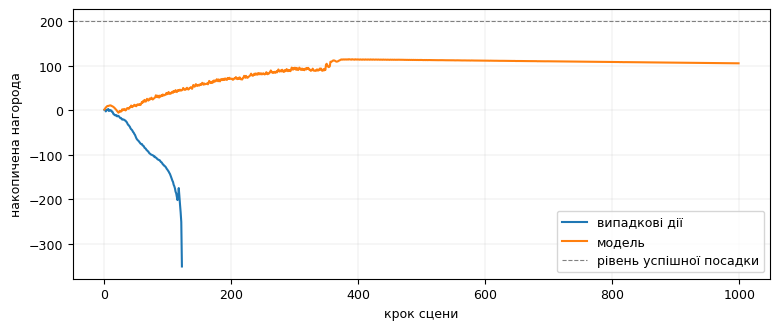


нагорода на кроці 380: 114.5 | у кінці: 105.9 | зміна за решту сцени: -8.6

останній стан сцени:
               позиція x:  0.155
               позиція y: -0.012
             швидкість x:  0.002
             швидкість y: -0.000
                     кут: -0.087
        кутова швидкість: -0.001
   ліва опора торкається:  1.000
  права опора торкається:  1.000


In [8]:
# Крок 8. Повний прогін сцени: випадкові дії проти моделі

# У Кроці 5 ми обірвали сцену на сотому кроці, тож ті числа непорівнянні з роботою моделі.
# Тепер доводимо обидві сцени до кінця з того самого старту і дивимось на накопичену нагороду.
def run_scene(policy, seed=42, max_steps=1000, collect_frames=False):
    env.action_space.seed(seed)
    obs, info = env.reset(seed=seed)
    scene_frames, scene_rewards, ending = [], [], "ліміт кроків"
    for step in range(max_steps):
        if collect_frames:
            scene_frames.append(env.render())
        if policy == "random":
            action = env.action_space.sample()
        else:
            action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env.step(int(action))
        scene_rewards.append(reward)
        if terminated:
            ending = "сцена завершилась"
            break
        if truncated:
            ending = "ліміт часу"
            break
    return scene_frames, np.array(scene_rewards), ending, obs

_, random_scene_rewards, random_ending, _ = run_scene("random")
_, model_scene_rewards, model_ending, model_last = run_scene("model")

for name, rewards, ending in [("випадкові дії", random_scene_rewards, random_ending),
                              ("модель", model_scene_rewards, model_ending)]:
    print(f"{name:>14}: кроків {len(rewards):4d} | нагорода {rewards.sum():8.1f} | {ending}")

random_cumulative = np.cumsum(random_scene_rewards)
model_cumulative = np.cumsum(model_scene_rewards)

plt.figure(figsize=(9, 3.5))
plt.plot(random_cumulative, label="випадкові дії")
plt.plot(model_cumulative, label="модель")
plt.axhline(200, linestyle="--", linewidth=0.8, color="gray", label="рівень успішної посадки")
plt.xlabel("крок сцени")
plt.ylabel("накопичена нагорода")
plt.legend()
plt.show()

# Крива моделі з середини сцени майже не рухається. Дивимось на числа і на останній стан.
flat_from = 380  # приблизно з цього кроку крива на графіку вирівнюється
print(f"\nнагорода на кроці {flat_from}: {model_cumulative[flat_from]:.1f}"
      f" | у кінці: {model_cumulative[-1]:.1f}"
      f" | зміна за решту сцени: {model_cumulative[-1] - model_cumulative[flat_from]:.1f}")
print("\nостанній стан сцени:")
for name, value in zip(state_names, model_last):
    print(f"{name:>24}: {value: .3f}")

# Випадкові дії завершили сцену за 123 кроки з великим мінусом.
# Модель уперлась у ліміт часу з нагородою 105.9, і за останні 620 кроків нагорода майже не
# змінилась. Останній стан показує, чому: обидві опори торкаються ґрунту, швидкості майже нульові.
# Тобто модуль сів і стоїть, але сцена формально не завершилась, і бонус за посадку не нарахувався.

старт 0: кроків  372 | нагорода   266.1 | сцена завершилась


старт 1: кроків  401 | нагорода   221.1 | сцена завершилась


старт 2: кроків  393 | нагорода   212.2 | сцена завершилась


старт 3: кроків  368 | нагорода   209.8 | сцена завершилась


старт 4: кроків  401 | нагорода   232.3 | сцена завершилась
старт 5: кроків  417 | нагорода   243.4 | сцена завершилась


старт 6: кроків  439 | нагорода   289.2 | сцена завершилась
старт 7: кроків  373 | нагорода   222.7 | сцена завершилась
старт 8: кроків  378 | нагорода   263.5 | сцена завершилась


старт 9: кроків  420 | нагорода   283.9 | сцена завершилась

середня нагорода 244.4 | вище 200 у 10 сценах з 10


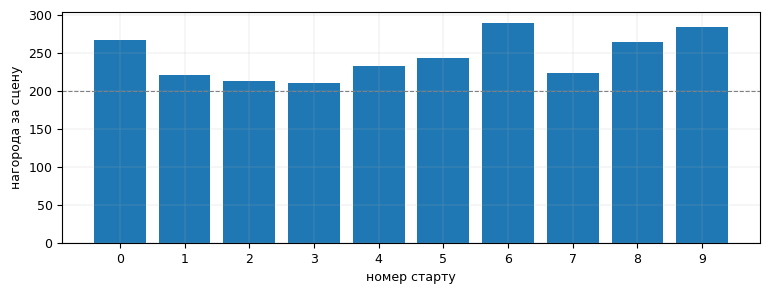

In [9]:
# Крок 9. Чи типова така сцена: перевіряємо на десяти стартах

# Одна сцена нічого не доводить, тому проганяємо модель з десяти різних початкових положень.
seed_totals = []
for seed in range(10):
    _, rewards, ending, _ = run_scene("model", seed=seed)
    seed_totals.append(rewards.sum())
    print(f"старт {seed}: кроків {len(rewards):4d} | нагорода {rewards.sum():7.1f} | {ending}")

seed_totals = np.array(seed_totals)
print(f"\nсередня нагорода {seed_totals.mean():.1f}"
      f" | вище 200 у {(seed_totals >= 200).sum()} сценах з 10")

plt.figure(figsize=(9, 3))
plt.bar(range(10), seed_totals)
plt.axhline(200, linestyle="--", linewidth=0.8, color="gray")
plt.xlabel("номер старту")
plt.ylabel("нагорода за сцену")
plt.xticks(range(10))
plt.show()

# На десяти інших стартах сцена щоразу завершується сама, і нагорода вища за 200.
# Тобто ліміт часу з Кроку 8 не є звичайною поведінкою моделі, а окремим випадком.
# У картці цієї моделі на HuggingFace заявлено середню нагороду 233.56 плюс-мінус 53.89.
# Наші 244.4 у цей діапазон вкладаються, тобто в нашому середовищі модель працює як обіцяно.

кадрів у сцені: 372 | нагорода: 266.1 | сцена завершилась


розмір анімації: 0.2 МБ


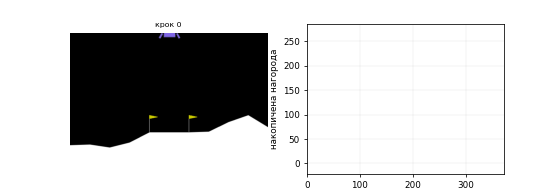

In [10]:
# Крок 10. Відео посадки

# Беремо старт 0: там сцена завершується сама і нагорода 266, тобто звичайна вдала посадка.
landing_frames, landing_rewards, landing_ending, _ = run_scene("model", seed=0, collect_frames=True)
landing_cumulative = np.cumsum(landing_rewards)
print("кадрів у сцені:", len(landing_frames),
      "| нагорода:", round(float(landing_cumulative[-1]), 1), "|", landing_ending)

# Показуємо кожен четвертий кадр, інакше анімація сильно роздує файл ноутбука.
shown_frames = range(0, len(landing_frames), 4)

fig, (ax_scene, ax_curve) = plt.subplots(1, 2, figsize=(8, 2.8), dpi=70)

def draw_frame(i):
    ax_scene.clear()
    ax_scene.imshow(landing_frames[i])
    ax_scene.axis("off")
    ax_scene.set_title(f"крок {i}", fontsize=8)
    ax_curve.clear()
    ax_curve.plot(landing_cumulative[:i + 1])
    ax_curve.set_xlim(0, len(landing_cumulative))
    ax_curve.set_ylim(landing_cumulative.min() - 20, landing_cumulative.max() + 20)
    ax_curve.set_xlabel("крок сцени")
    ax_curve.set_ylabel("накопичена нагорода")

scene_animation = animation.FuncAnimation(fig, draw_frame, frames=shown_frames, interval=60)
plt.close(fig)

# Зберігаємо анімацію як gif і показуємо картинкою. Інтерактивний плеєр тримається на скриптах,
# а їх показ ноутбука на сторінці репозиторію вирізає, і замість анімації лишаються самі підписи.
with tempfile.NamedTemporaryFile(suffix=".gif") as gif_file:
    scene_animation.save(gif_file.name, writer=animation.PillowWriter(fps=16))
    animation_bytes = gif_file.read()

print("розмір анімації:", round(len(animation_bytes) / 1024 / 1024, 2), "МБ")
Image(data=animation_bytes, format="gif")

In [11]:
# Крок 11. Висновки

# Готова модель з HuggingFace запускається без жодного тренування, треба лише завантажити архів.
# Цей конкретний архів старий, тому простори станів і дій довелось підставити зі свого середовища.

# На довільній послідовності зі ста кадрів випадкові дії набрали -133, і модуль за цей час
# жодного разу не наблизився до майданчика, а частину часу взагалі був за межами екрана.

# На тих самих станах модель радить лише дві дії з чотирьох: лівий і головний двигун.
# Варіант нічого не робити вона не обрала жодного разу.

# У повній сцені з одного старту випадкові дії завершили політ за 123 кроки з нагородою -351,
# а модель довела модуль до землі й поставила його на обидві опори.

# Одна сцена може ввести в оману. На старті 42 нагорода 105.9 схожа на невдачу, але останній
# стан показує модуль на ґрунті з нульовими швидкостями: сцена просто не завершилась до ліміту
# і бонус за посадку не нарахувався. Тому перевіряли на десяти стартах.

# На десяти стартах модель садить модуль щоразу, середня нагорода 244.4, і всі сцени вище 200.

# Модель оцінює не лише дію, а й сам стан. На довільній послідовності оцінка почалась зі 113.4
# і впала до 52.1 у другій половині, коли модуль перекинувся.